# **LAB ASSIGNMENT - 5**

**Install & Import Libraries**

In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import mixed_precision
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

mixed_precision.set_global_policy('float32')

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Define U-Net Model**

In [2]:
# U-NET BLOCK

def unet_block(x, filters):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    return x

# BUILD U-NET

def build_unet(input_shape=(96,96,3), num_classes=1):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = unet_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = unet_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    bn = unet_block(p2, 128)

    # Decoder
    u1 = layers.UpSampling2D()(bn)
    u1 = layers.Concatenate()([u1, c2])
    c3 = unet_block(u1, 64)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = unet_block(u2, 32)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)


model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 24, 24,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 24,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 48, 48,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 48,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 48, 48,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 48, 48,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 96, 96,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96, 96,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 96, 96,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 96, 96,    │      9,248 │ conv2d_8[0][0]  

 Total params: 471,553 (1.80 MB)

 Trainable params: 471,553 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
from google.colab import files
uploaded = files.upload()

Saving German-Shepherd-dog-Alsatian.webp to German-Shepherd-dog-Alsatian.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


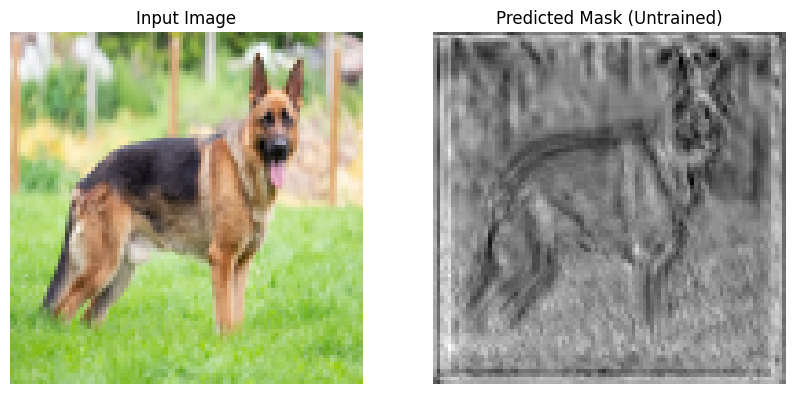

In [13]:
# PART 2: SINGLE IMAGE DEMO

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 96   # same as model input size

# Replace filename with your uploaded file name
img = Image.open("/content/German-Shepherd-dog-Alsatian.webp")
img = img.resize((IMG_SIZE, IMG_SIZE))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0);

# Forward pass
prediction = model.predict(img_array)

# Visualization
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img_array[0])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask (Untrained)")
plt.imshow(prediction[0,:,:,0], cmap='gray')
plt.axis("off")

plt.show()

**Load Oxford Pet Dataset**

In [14]:
dataset, info = tfds.load('oxford_iiit_pet:4.0.0',
                          with_info=True)

train_data = dataset['train']
test_data = dataset['test']

print("Train Samples:", info.splits['train'].num_examples)
print("Test Samples:", info.splits['test'].num_examples)

Train Samples: 3680
Test Samples: 3669


**Preprocessing**

In [15]:
IMG_SIZE = 96

def preprocess(data):

    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE))

    image = image / 255.0
    mask = tf.cast(mask == 2, tf.float32)  # Pet class only
    mask = tf.expand_dims(mask[:,:,0], axis=-1)

    return image, mask


train_data = train_data.map(preprocess).take(800).batch(4)
test_data = test_data.map(preprocess).take(200).batch(4)

print("Dataset Ready")

Dataset Ready


**Compile Model**

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


**Train Model**

In [18]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7747 - loss: 0.4876 - val_accuracy: 0.7691 - val_loss: 0.5165
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7933 - loss: 0.4614 - val_accuracy: 0.7970 - val_loss: 0.4574
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8072 - loss: 0.4366 - val_accuracy: 0.8139 - val_loss: 0.4206
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8189 - loss: 0.4137 - val_accuracy: 0.8273 - val_loss: 0.3912
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8207 - loss: 0.4050 - val_accuracy: 0.8312 - val_loss: 0.3845


**Add IoU Metric**

In [19]:
def iou_metric(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', iou_metric]
)

results = model.evaluate(test_data)
print("Test Results:", results)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8319 - iou_metric: 0.7520 - loss: 0.3798
Test Results: [0.3844761550426483, 0.8311941623687744, 0.7508738040924072]


**Visualize Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


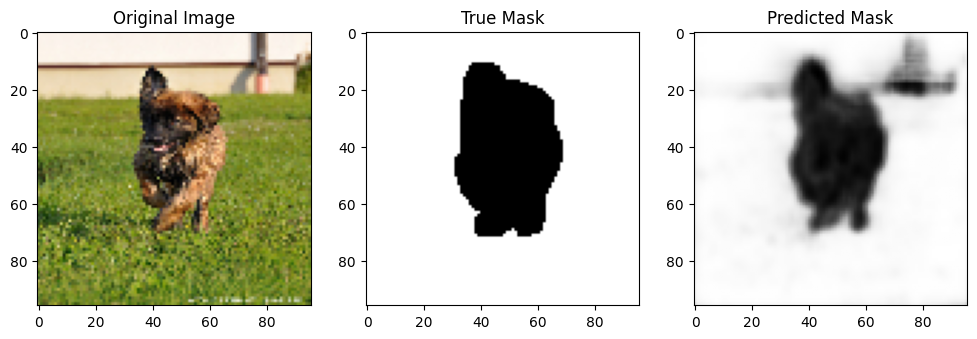

In [22]:
for images, masks in test_data.take(1):

    preds = model.predict(images)

    plt.figure(figsize=(12,6))

    plt.subplot(1,3,1)
    plt.title("Original Image")
    plt.imshow(images[0])

    plt.subplot(1,3,2)
    plt.title("True Mask")
    plt.imshow(masks[0,:,:,0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Predicted Mask")
    plt.imshow(preds[0,:,:,0], cmap='gray')

    plt.show()

**Training Curves**

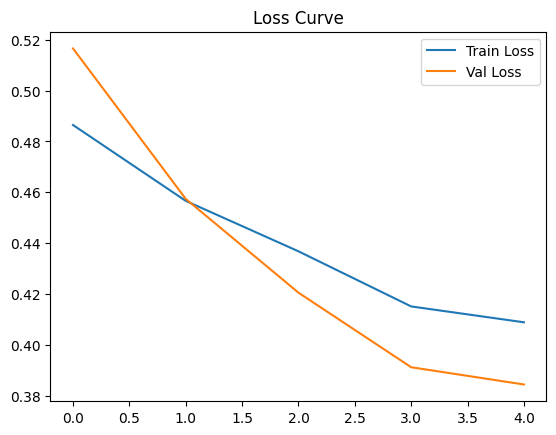

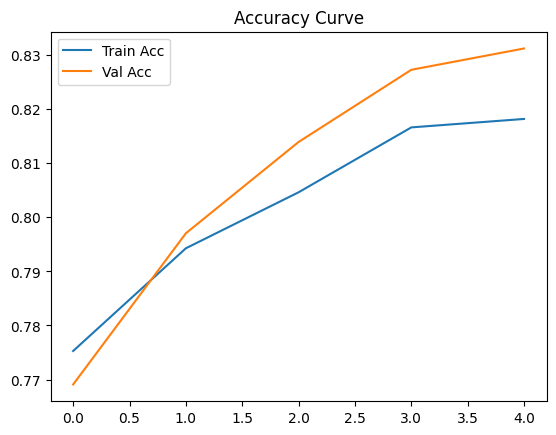

In [24]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

**Summary:**
In this lab, we implemented the U-Net model for semantic image segmentation. A small U-Net was first tested on a single image to understand how pixel-level predictions are generated. Then, the Oxford-IIIT Pet dataset was preprocessed and used to train the model using resized and normalized images along with segmentation masks. The model was trained for a few epochs on GPU and evaluated using accuracy and IoU metrics. The results showed that U-Net effectively performs detailed image segmentation due to its encoder–decoder structure and skip connections.